In [1]:
import socket, sys
socket.gethostname(), sys.executable


('login3', '/project/def-nahee/kbas/pone_offline/graphnet_env/bin/python')


#### The residual in logarithm of energy prediction is evaluated in this script. Why `residual_log10`?

This is especially convenient when the energy spans many orders of magnitude.


#### Definition of `residual_log10`


$ \mathrm{residual\_log10} = \widehat{\log_{10}E} - \log_{10}(E_\mathrm{true}) $




#### Interpreting the sign of `residual_log10`

- `residual_log10 = 0` → perfect prediction  
- `residual_log10 > 0` → the model **overpredicts** energy  
- `residual_log10 < 0` → the model **underpredicts** energy


#### Quantiles: p16, p50, p84

To summarize the distribution of `residual_log10`:

- **p50** = median (middle value) → can be interpreted as **bias**
- **p16** and **p84** = the 16th and 84th percentiles  
  (If the residuals were Gaussian, these would roughly correspond to **±1σ** around the median.)


#### Resolution proxy: W

I define a resolution-like width using the central 68% interval:

$ W = \frac{p84 - p16}{2} $

Interpretation:
- **Small W** → tighter residual distribution → **better resolution**
- **Large W** → wider residual distribution → **worse resolution**

**Note:** W is measured in **log10-error units**, not directly in “% error”.


# 0. Setup


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Consistent plotting defaults (no subsampling anywhere in this notebook)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})


Note: the energy model predicts **log10(E)**-space quantities, and `energy_pred` is reconstructed from that.


In [3]:
energy_test_predictions_path = Path("../energy") / "test_predictions.csv"
energy_metrics_path =  Path("../energy") /"metrics.csv"
energy_resources_and_time_path =  Path("../energy") /"resources_and_time.csv"

df_energy_test_predictions = pd.read_csv(energy_test_predictions_path)
df_energy_metrics = pd.read_csv(energy_metrics_path)
df_energy_resources_and_time = pd.read_csv(energy_resources_and_time_path)



# 1. Test Predictions (event-level)


## 1.1 Workflow
a) Confirm schema and NaNs/Infs  
b) Inspect the global residual distribution  
c) Inspect residual vs truth (trend + spread)  
d) Quantify resolution with **W** (equal-width and equal-population bins)  
e) Assess bias (median residual; and where relevant a ratio-based view)


## 1.2 Schema and integrity checks


In [4]:
print("shape:", df_energy_test_predictions.shape)
print("columns:", list(df_energy_test_predictions.columns))


shape: (23889, 7)
columns: ['true_energy', 'pred_energy', 'pred_log10_energy', 'true_log10_energy', 'residual_log10', 'residual', 'event_id']


In [5]:
df_energy_test_predictions.head(3)
## residual log10 negatif olunca residual da mi negatif olcak. isaretler hep tutarli mi olmali.


,true_energy,pred_energy,pred_log10_energy,true_log10_energy,residual_log10,residual,event_id
0,135.932602,269.209961,2.430091,2.133324,0.296767,133.277359,8
1,104.624199,173.271957,2.238728,2.019632,0.219096,68.647758,613
2,133.357361,210.169571,2.322570,2.125017,0.197553,76.812210,850


In [6]:
print("Rows:", len(df_energy_test_predictions))

print("\nNaN counts (all columns):")
print(df_energy_test_predictions.isna().sum())


Rows: 23889

NaN counts (all columns):
true_energy          0
pred_energy          0
pred_log10_energy    0
true_log10_energy    0
residual_log10       0
residual             0
event_id             0
dtype: int64


In [7]:
# Inf / -Inf counts in numeric columns (auto)
num_df = df_energy_test_predictions.apply(pd.to_numeric, errors="coerce")

inf_pos = np.isposinf(num_df).sum()
inf_neg = np.isneginf(num_df).sum()
inf_any = np.isinf(num_df).sum()

out = pd.DataFrame({
    "+inf": inf_pos,
    "-inf": inf_neg,
    "any_inf": inf_any
}).sort_values("any_inf", ascending=False)

print("Inf counts (numeric columns):")
print(out)


Inf counts (numeric columns):
                   +inf  -inf  any_inf
true_energy           0     0        0
pred_energy           0     0        0
pred_log10_energy     0     0        0
true_log10_energy     0     0        0
residual_log10        0     0        0
residual              0     0        0
event_id              0     0        0


## 1.3 Column ranges (min / max)


In [8]:
# Column ranges (min/max) for key fields
cols = [
    "true_energy",
    "pred_energy",
    "true_log10_energy",
    "pred_log10_energy",
    "residual",
    "residual_log10",
]
cols = [c for c in cols if c in df_energy_test_predictions.columns]

for c in cols:
    v = df_energy_test_predictions[c].to_numpy()
    print(f"{c:>16s}: {np.nanmin(v): .6g} .. {np.nanmax(v): .6g}")


     true_energy:  100.017 ..  9.93182e+06
     pred_energy:  68.0417 ..  3.08727e+07
true_log10_energy:  2.00008 ..  6.99703
pred_log10_energy:  1.83278 ..  7.48957
        residual: -9.92447e+06 ..  2.86963e+07
  residual_log10: -4.33251 ..  2.48086


In [9]:
# true_energy <= 0 check 
true_e = pd.to_numeric(df_energy_test_predictions["true_energy"], errors="coerce")
print("\ntrue_energy <= 0:", (true_e <= 0).sum())



true_energy <= 0: 0


## 1.4 Global summary (quantiles and W)


In [10]:
# ---- Energy: global W over the full test set ----
r = df_energy_test_predictions["residual_log10"].to_numpy(dtype=float)
p16, p50, p84 = np.quantile(r, [0.16, 0.50, 0.84])
W = (p84 - p16) / 2

print(f"p16={p16:.4f}, p50={p50:.4f}, p84={p84:.4f}, W={W:.4f}")


p16=-0.4117, p50=0.0659, p84=0.4086, W=0.4101


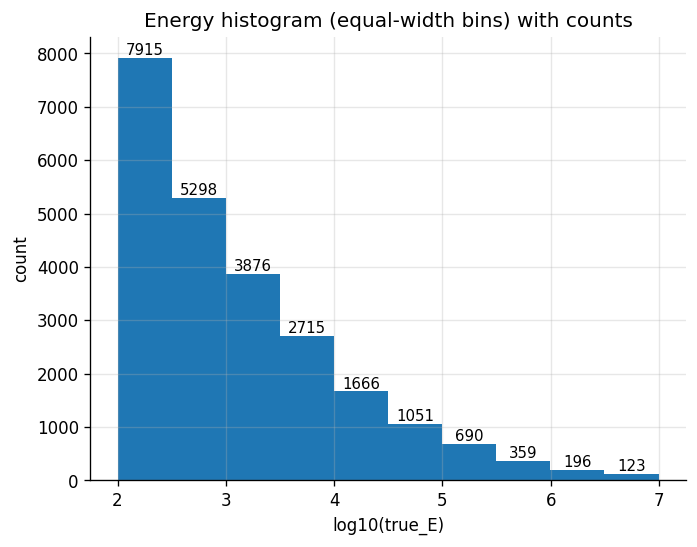

In [11]:
# ---- Energy: histogram with counts annotated on top of bars ----
n_bins_energy = 10
bins_energy = np.linspace(
    df_energy_test_predictions["true_log10_energy"].min(),
    df_energy_test_predictions["true_log10_energy"].max(),
    n_bins_energy + 1,
)
values = df_energy_test_predictions["true_log10_energy"].to_numpy()

plt.figure()
counts, edges, patches = plt.hist(values, bins=bins_energy)

# annotate each bar with its count
for c, left, right in zip(counts, edges[:-1], edges[1:]):
    if c <= 0:
        continue
    x = 0.5 * (left + right)
    plt.text(x, c, f"{int(c)}", ha="center", va="bottom", fontsize=9)

plt.xlabel("log10(true_E)")
plt.ylabel("count")
plt.title("Energy histogram (equal-width bins) with counts")
plt.grid(True, alpha=0.3)
plt.show()


## 1.5 Residual distribution


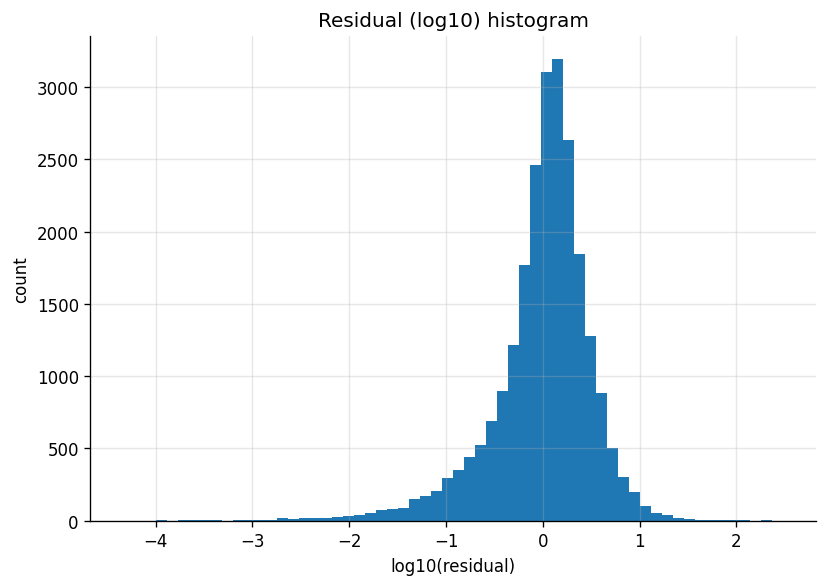

In [12]:
# ---- Energy: residual_log10 histogram (full test set) ----
r = df_energy_test_predictions["residual_log10"].to_numpy(dtype=float)
plt.figure(figsize=(7, 5))
plt.hist(r, bins=60)
plt.xlabel("log10(residual)")
plt.ylabel("count")
plt.title("Residual (log10) histogram") # buraya formulu yazabilirsin.
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1.6 Residual vs truth (trend + spread)



This diagnostic shows how the **log10 residual** behaves across the energy range:

- Each blue point is one event:  
  $r = \widehat{\log_{10}E} - \log_{10}(E_\mathrm{true})$  
- The horizontal line at $r=0$ is the **ideal** case (no bias).
- The red curve is the **binned median** of the residual, which highlights the typical trend.

What to look for:
- If the red curve stays near 0 → the model is **well-calibrated** across energies.
- If it drifts above 0 → systematic **overestimation**.
- If it drifts below 0 → systematic **underestimation**.
- If the vertical spread increases with energy → **worsening resolution** (larger event-to-event scatter).


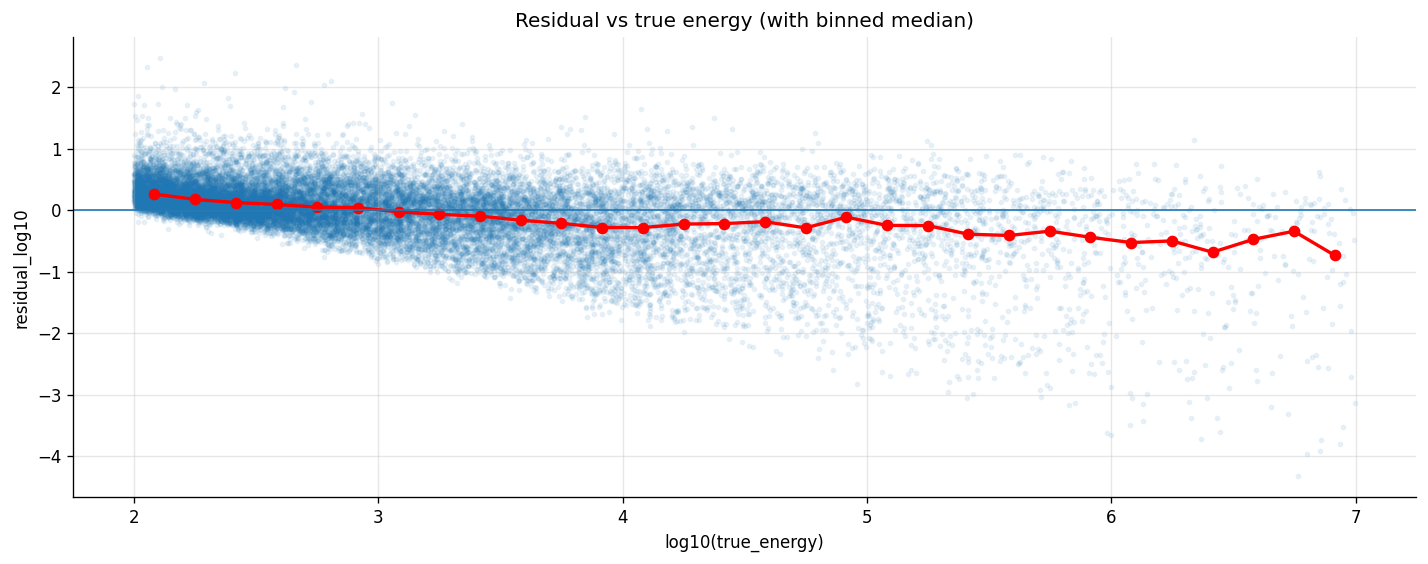

In [13]:
# ---- Energy: residual vs true_log10_energy scatter + binned median ----

x = df_energy_test_predictions["true_log10_energy"].to_numpy(dtype=float)

plt.figure(figsize=(12, 4.8))
plt.scatter(x, r, s=6, alpha=0.08)

# binned median (equal-width in x)
n_bins = 30
bins = np.linspace(x.min(), x.max(), n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

median_r = []
for left, right in zip(bins[:-1], bins[1:]):
    m = (x >= left) & (x < right) if right != bins[-1] else (x >= left) & (x <= right)
    median_r.append(np.median(r[m]) if np.any(m) else np.nan)

median_r = np.array(median_r, dtype=float)

# plot median curve
plt.plot(bin_centers, median_r, marker="o", linewidth=2, color="r")

# reference line
plt.axhline(0.0, linestyle="-", linewidth=1)

plt.xlabel("log10(true_energy)")
plt.ylabel("residual_log10") # formulu yaz
plt.title("Residual vs true energy (with binned median)") # ismi degis
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 1.7 Calibration (predicted vs true)


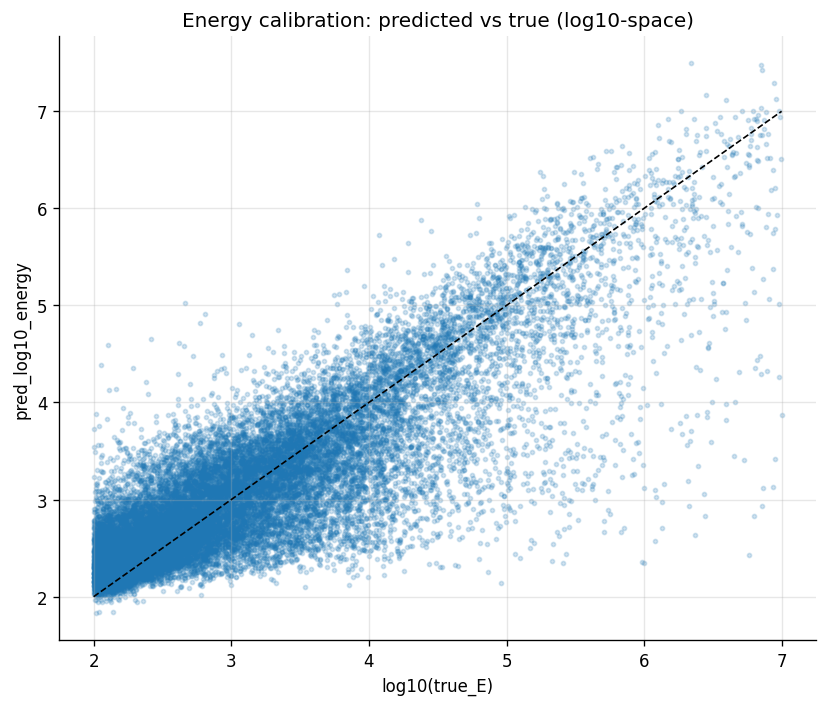

In [14]:
# ---- Energy: calibration scatter (pred_log10 vs true_log10) ----

plt.figure(figsize=(7, 6))  # bigger figure

plt.scatter(
    df_energy_test_predictions["true_log10_energy"],
    df_energy_test_predictions["pred_log10_energy"],
    s=6, alpha=0.2
)

xmin = df_energy_test_predictions["true_log10_energy"].min()
xmax = df_energy_test_predictions["true_log10_energy"].max()

plt.plot([xmin, xmax], [xmin, xmax], color="black", linestyle="--", linewidth=1)  # y=x in black

plt.xlabel("log10(true_E)")
plt.ylabel("pred_log10_energy")
plt.title("Energy calibration: predicted vs true (log10-space)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



The calibration plot compares the model prediction to the truth directly:

- x-axis: $\log_{10}(E_\mathrm{true})$  
- y-axis: $\widehat{\log_{10}E}$

The reference line $y=x$ corresponds to perfect calibration.
Points below the line indicate underestimation; above the line indicate overestimation.


## 1.8 Resolution vs truth (W)


### 1.8.1: equal-width bins

In [15]:
df_energy_w_rows = []
for left, right in zip(edges[:-1], edges[1:]):
    # select events in this bin (match matplotlib hist logic: [left, right) except last bin includes right)
    if right == edges[-1]:
        mask = (df_energy_test_predictions["true_log10_energy"] >= left) & (df_energy_test_predictions["true_log10_energy"] <= right)
    else:
        mask = (df_energy_test_predictions["true_log10_energy"] >= left) & (df_energy_test_predictions["true_log10_energy"] < right)

    r = df_energy_test_predictions.loc[mask, "residual_log10"].to_numpy(dtype=float)

    # skip empty bins (shouldn't happen, but safe)
    if r.size == 0:
        continue

    p16, p50, p84 = np.quantile(r, [0.16, 0.50, 0.84])
    W = (p84 - p16) / 2
    center = 0.5 * (left + right)

    df_energy_w_rows.append({
        "Ebin": f"({left:.3f}, {right:.3f}]",
        "E_center_log10": center,
        "count": int(r.size),
        "p16": p16,
        "p50": p50,
        "p84": p84,
        "W": W,
    })

df_energy_W_table = pd.DataFrame(df_energy_w_rows)
df_energy_W_table


,Ebin,E_center_log10,count,p16,p50,p84,W
0,"(2.000, 2.500]",2.249923,7915,-0.000478,0.200423,0.491836,0.246157
1,"(2.500, 2.999]",2.749618,5298,-0.228512,0.064800,0.449836,0.339174
2,"(2.999, 3.499]",3.249314,3876,-0.500913,-0.053205,0.328777,0.414845
3,"(3.499, 3.999]",3.749009,2715,-0.802635,-0.217124,0.238273,0.520454
4,"(3.999, 4.499]",4.248704,1666,-1.056464,-0.237315,0.284575,0.670519
5,"(4.499, 4.998]",4.748400,1051,-1.128907,-0.181743,0.281895,0.705401
6,"(4.998, 5.498]",5.248095,690,-1.371405,-0.285820,0.315563,0.843484
7,"(5.498, 5.998]",5.747790,359,-1.807152,-0.402112,0.226063,1.016607
8,"(5.998, 6.497]",6.247486,196,-1.890213,-0.519710,0.172006,1.031110
9,"(6.497, 6.997]",6.747181,123,-2.116538,-0.488214,0.086374,1.101456


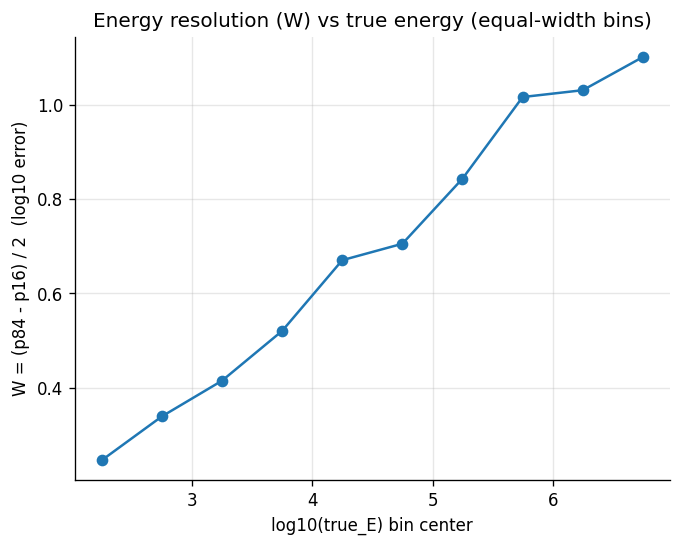

In [16]:
# ---- Energy: plot W vs true energy (equal-width bins) ----

plt.figure()
plt.plot(df_energy_W_table["E_center_log10"], df_energy_W_table["W"], marker="o")
plt.xlabel("log10(true_E) bin center")
plt.ylabel("W = (p84 - p16) / 2  (log10 error)")
plt.title("Energy resolution (W) vs true energy (equal-width bins)")
plt.grid(True, alpha=0.3)
plt.show()


In the **equal-width** energy binning, the number of events per bin is **not uniform**.  
At higher energies the bins contain **much fewer events**, so the quantile estimates (p16/p50/p84) become **statistically unstable**. This can artificially inflate the width  
$W = (p84 - p16)/2$ and make it look like the resolution worsens rapidly with energy.

To reduce this sampling effect, we next repeat the same analysis using **equal-population bins** (i.e., bins with approximately the same number of events) and compare the results.


### 1.8.2: equal-population bins

In [17]:
# ---- create equal-population bins (qcut) ----

n_qbins_energy = 10

df_energy_test_predictions["Ebin_q"] = pd.qcut(
    df_energy_test_predictions["true_log10_energy"],
    q=n_qbins_energy,
    duplicates="drop",
)


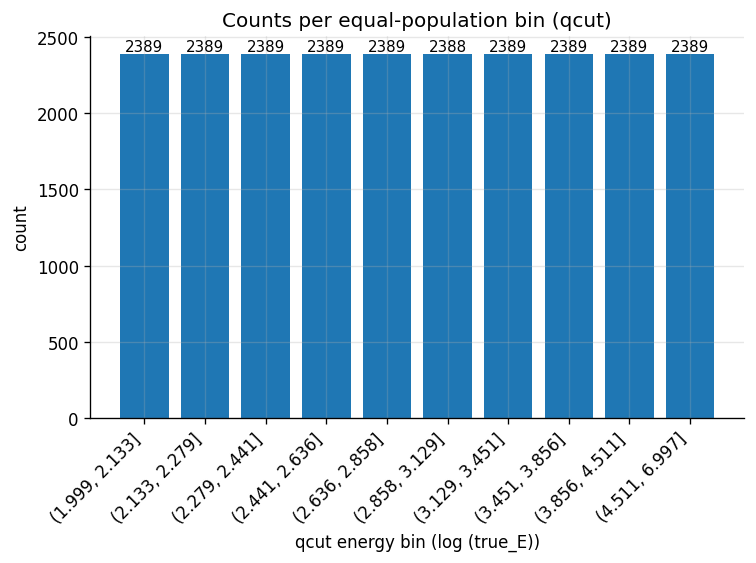

In [18]:
# ----  plot counts per qcut bin ----

bin_counts_q = df_energy_test_predictions["Ebin_q"].value_counts().sort_index()

plt.figure()
bars = plt.bar(range(len(bin_counts_q)), bin_counts_q.to_numpy())
plt.xticks(range(len(bin_counts_q)), [str(i) for i in bin_counts_q.index], rotation=45, ha="right")
plt.xlabel("qcut energy bin (log (true_E))")
plt.ylabel("count")
plt.title("Counts per equal-population bin (qcut)")
plt.grid(True, axis="y", alpha=0.3)

# annotate counts on top of bars
for i, c in enumerate(bin_counts_q.to_numpy()):
    plt.text(i, c, str(int(c)), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


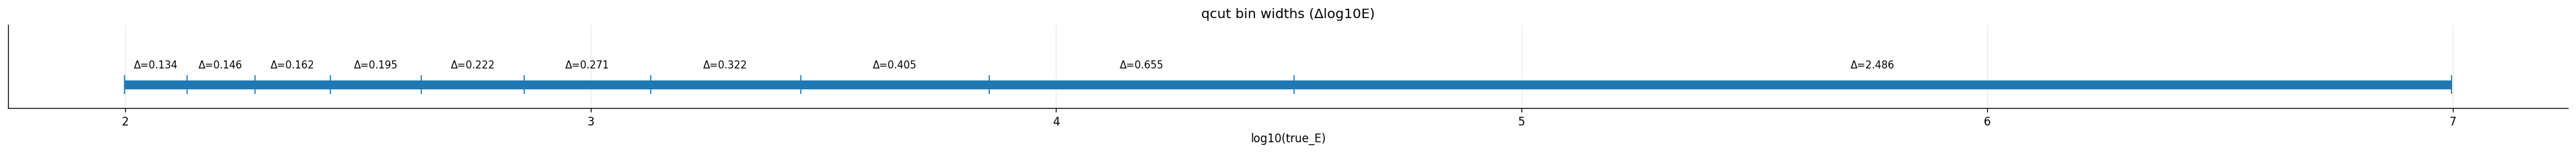

In [19]:
# ---- Visualize qcut bin widths only (in log10-space) ----

# intervals in correct order
intervals = bin_counts_q.index  # IntervalIndex from your existing bin_counts_q

lefts  = np.array([iv.left for iv in intervals], dtype=float)
rights = np.array([iv.right for iv in intervals], dtype=float)
widths = rights - lefts
centers = (lefts + rights) / 2

plt.figure(figsize=(32, 2))

# draw each bin as a horizontal segment
for L, R, w, x in zip(lefts, rights, widths, centers):
    plt.hlines(0, L, R, linewidth=8)
    plt.text(x, 0.12, f"Δ={w:.3f}", ha="center", va="bottom", fontsize=9)

# draw bin boundaries as small ticks
for x in lefts:
    plt.vlines(x, -0.08, 0.08, linewidth=1)
plt.vlines(rights[-1], -0.08, 0.08, linewidth=1)

plt.yticks([])
plt.xlabel("log10(true_E)")
plt.title("qcut bin widths (Δlog10E)")
plt.ylim(-0.2, 0.5)
plt.tight_layout()
plt.show()


In [20]:
# ---- Energy: p16/p50/p84 and W per qcut bin (use groupby directly; no remasking) ----

rows_energy_q = []
for iv, g in df_energy_test_predictions.groupby("Ebin_q", observed=True):
    r = g["residual_log10"].to_numpy(dtype=float)

    p16, p50, p84 = np.quantile(r, [0.16, 0.50, 0.84])
    W = (p84 - p16) / 2
    center = 0.5 * (float(iv.left) + float(iv.right))

    rows_energy_q.append({
        "Ebin_q": str(iv),
        "E_center_log10": center,
        "count": int(len(g)),
        "p16": p16,
        "p50": p50,
        "p84": p84,
        "W": W,
    })

df_energy_W_table_q = pd.DataFrame(rows_energy_q).sort_values("E_center_log10")
df_energy_W_table_q


,Ebin_q,E_center_log10,count,p16,p50,p84,W
0,"(1.999, 2.133]",2.0660,2389,0.099809,0.278918,0.551461,0.225826
1,"(2.133, 2.279]",2.2060,2389,0.009422,0.189798,0.463570,0.227074
2,"(2.279, 2.441]",2.3600,2389,-0.055538,0.145951,0.465811,0.260675
3,"(2.441, 2.636]",2.5385,2389,-0.135346,0.095231,0.438371,0.286858
4,"(2.636, 2.858]",2.7470,2389,-0.244478,0.055603,0.447710,0.346094
5,"(2.858, 3.129]",2.9935,2388,-0.362882,0.018794,0.417245,0.390063
6,"(3.129, 3.451]",3.2900,2389,-0.546218,-0.063612,0.313830,0.430024
7,"(3.451, 3.856]",3.6535,2389,-0.747895,-0.179340,0.252699,0.500297
8,"(3.856, 4.511]",4.1835,2389,-1.019387,-0.254456,0.254918,0.637152
9,"(4.511, 6.997]",5.7540,2389,-1.352800,-0.282157,0.271682,0.812241


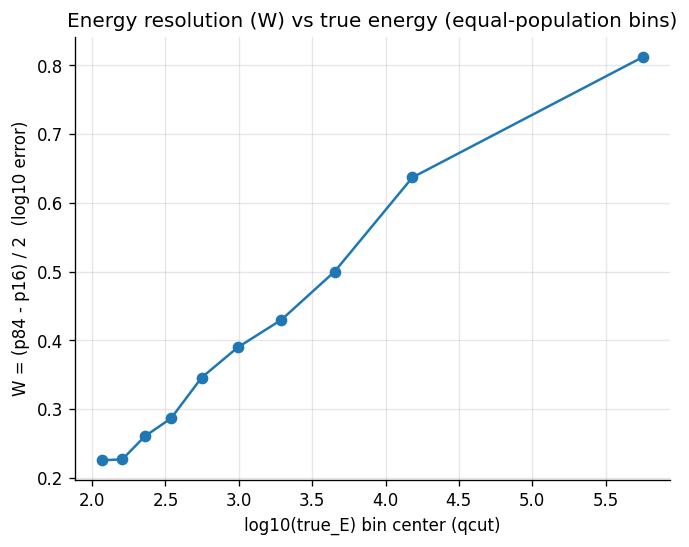

In [21]:
# ---- Energy: plot W vs true energy (qcut bins) ----

plt.figure()
plt.plot(df_energy_W_table_q["E_center_log10"], df_energy_W_table_q["W"], marker="o")
plt.xlabel("log10(true_E) bin center (qcut)")
plt.ylabel("W = (p84 - p16) / 2  (log10 error)")
plt.title("Energy resolution (W) vs true energy (equal-population bins)")
plt.grid(True, alpha=0.3)
plt.show()


So far we focused on **resolution**, summarized by  
$W = (p84 - p16)/2$, computed from the `residual_log10` distribution in each energy bin.

Resolution tells us **how wide** the error distribution is.

Next, we examine **bias**:  
Does the model systematically **overestimate** or **underestimate** the energy, and does this depend on energy?


## 1.9 Bias diagnostics: two approaches



- **Median residual vs energy**  
   Plot $p50(\mathrm{residual\_log10})$ as a function of energy.  
   This is the most direct bias measure in log-space.

- **Median pred/true ratio vs energy**  
   Convert the median residual into a multiplicative ratio  
   $\mathrm{median}(E_\mathrm{pred}/E_\mathrm{true}) = 10^{p50}$  
   to make the bias more intuitive.


### 1.9.1: median residual vs energy (log-space bias)

If we define  
$\mathrm{residual\_log10} = \widehat{\log_{10}E} - \log_{10}(E_\mathrm{true})$,

then:

- $p50 \approx 0$ → unbiased in that energy region  
- $p50 > 0$ → overestimation  
- $p50 < 0$ → underestimation


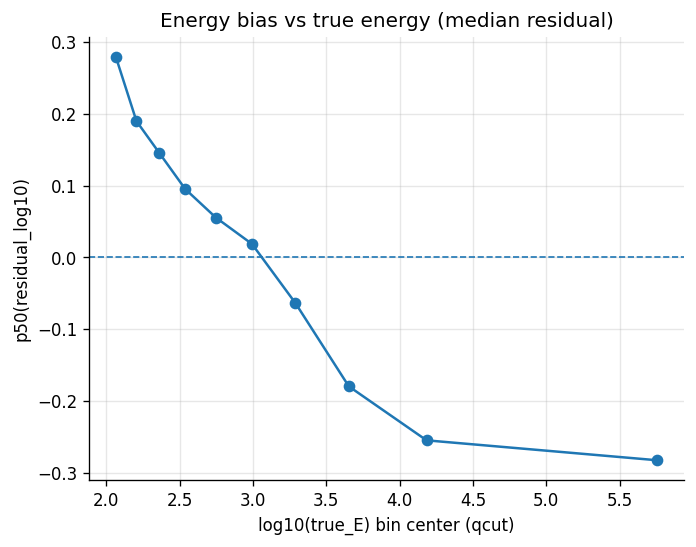

In [22]:
# ----  bias vs true energy (median residual, qcut bins) ----

plt.figure()
plt.plot(df_energy_W_table_q["E_center_log10"], df_energy_W_table_q["p50"], marker="o")
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("log10(true_E) bin center (qcut)")
plt.ylabel("p50(residual_log10)")
plt.title("Energy bias vs true energy (median residual)")
plt.grid(True, alpha=0.3)
plt.show()


### 1.9.2: median pred/true ratio vs energy (pred/true)

Because the residual is in log10-space, it can be converted into a multiplicative ratio:

$ \frac{E_\mathrm{pred}}{E_\mathrm{true}} = 10^{\mathrm{residual\_log10}} $

So the median bias ratio per bin is:

$ \mathrm{median}(E_\mathrm{pred}/E_\mathrm{true}) = 10^{p50} $

Interpretation:
- ratio ≈ 1 → unbiased
- ratio < 1 → underestimation
- ratio > 1 → overestimation


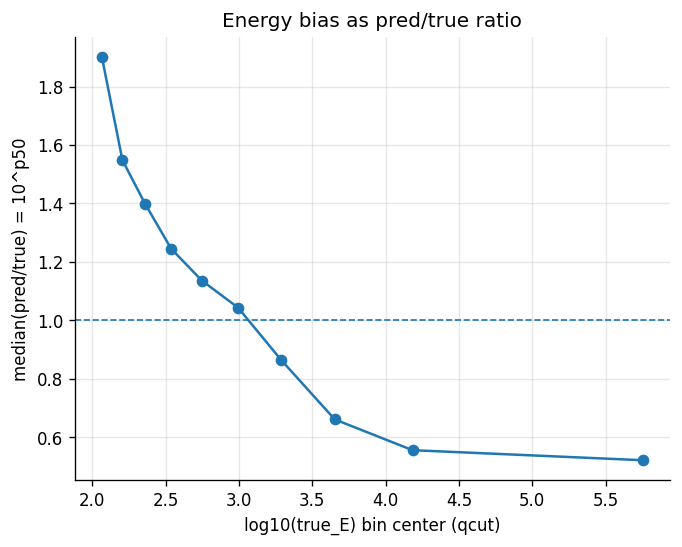

In [23]:
# ---- bias as pred/true ratio (qcut bins) ----

df_energy_W_table_q["ratio50"] = 10 ** (df_energy_W_table_q["p50"])

plt.figure()
plt.plot(df_energy_W_table_q["E_center_log10"], df_energy_W_table_q["ratio50"], marker="o")
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xlabel("log10(true_E) bin center (qcut)")
plt.ylabel("median(pred/true) = 10^p50")
plt.title("Energy bias as pred/true ratio")
plt.grid(True, alpha=0.3)
plt.show()


# 2. Training Metrics (epoch-level)


## 2.1 Overview


In [24]:
print("shape:", df_energy_metrics.shape)
print("columns:", list(df_energy_metrics.columns))


shape: (23, 12)
columns: ['epoch', 'train_loss', 'val_loss', 'lr', 'best_model_is_updated', 'val_residual_log10_p16', 'val_residual_log10_p50', 'val_residual_log10_p84', 'val_W_log10', 'val_bias_log10', 'val_mae_log10', 'val_rmse_log10']


In [25]:
# Identify the epoch where the best model was last updated
if "best_model_is_updated" in df_energy_metrics.columns:
    _mask = df_energy_metrics["best_model_is_updated"].astype(bool)
    best_epoch = int(df_energy_metrics.loc[_mask, "epoch"].max()) if _mask.any() else None
else:
    best_epoch = None

print(f"Best-model epoch (last update): {best_epoch}")


Best-model epoch (last update): 17


In [26]:
df_energy_metrics.head(5)


,epoch,train_loss,val_loss,lr,best_model_is_updated,val_residual_log10_p16,val_residual_log10_p50,val_residual_log10_p84,val_W_log10,val_bias_log10,val_mae_log10,val_rmse_log10
0,0,NaN,0.183273,0.000983,True,-0.605862,0.024045,0.443821,0.524842,-0.062501,0.479292,0.719749
1,1,0.493633,0.146430,0.000950,True,-0.588193,0.001859,0.399574,0.493884,-0.104254,0.427937,0.610754
2,2,0.159917,0.136662,0.000916,True,-0.535618,0.024282,0.407914,0.471766,-0.075841,0.412392,0.585863
3,3,0.144110,0.132036,0.000883,True,-0.531510,0.011134,0.397446,0.464478,-0.079790,0.402945,0.573792
4,4,0.134511,0.127371,0.000849,True,-0.466860,0.058385,0.433791,0.450326,-0.027690,0.397770,0.559671


## 2.2 Training curves (loss & LR)


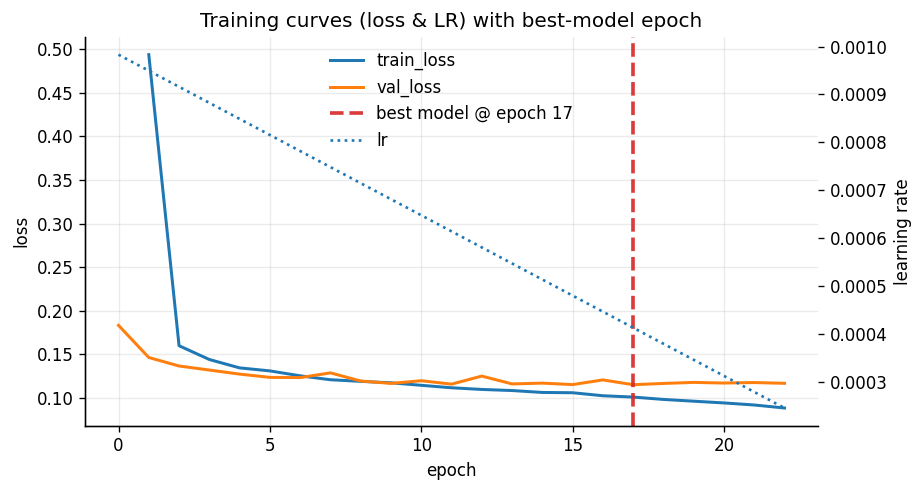

In [27]:
fig, ax = plt.subplots(figsize=(7.8, 4.2))

ax.plot(df_energy_metrics["epoch"], df_energy_metrics["train_loss"], label="train_loss", linewidth=1.8)
ax.plot(df_energy_metrics["epoch"], df_energy_metrics["val_loss"], label="val_loss", linewidth=1.8)

# Best-model epoch (last update)
if "best_model_is_updated" in df_energy_metrics.columns:
    _mask = df_energy_metrics["best_model_is_updated"].astype(bool)
    _best_epoch = int(df_energy_metrics.loc[_mask, "epoch"].max()) if _mask.any() else None
else:
    _best_epoch = None

if _best_epoch is not None:
    ax.axvline(
        _best_epoch,
        color="tab:red",
        linestyle="--",
        linewidth=2.2,
        alpha=0.9,
        label=f"best model @ epoch {_best_epoch}",
    )

ax.set_xlabel("epoch")
ax.set_ylabel("loss")

ax2 = None
if "lr" in df_energy_metrics.columns:
    ax2 = ax.twinx()
    ax2.plot(df_energy_metrics["epoch"], df_energy_metrics["lr"], label="lr", linestyle=":", linewidth=1.6)
    ax2.set_ylabel("learning rate")
    ax2.grid(False)

# Combined legend
handles, labels = ax.get_legend_handles_labels()
if ax2 is not None:
    h2, l2 = ax2.get_legend_handles_labels()
    handles += h2
    labels += l2
ax.legend(handles, labels, loc="best")

ax.set_title("Training curves (loss & LR) with best-model epoch")
fig.tight_layout()
plt.show()


## 2.3 Key validation metrics over epochs


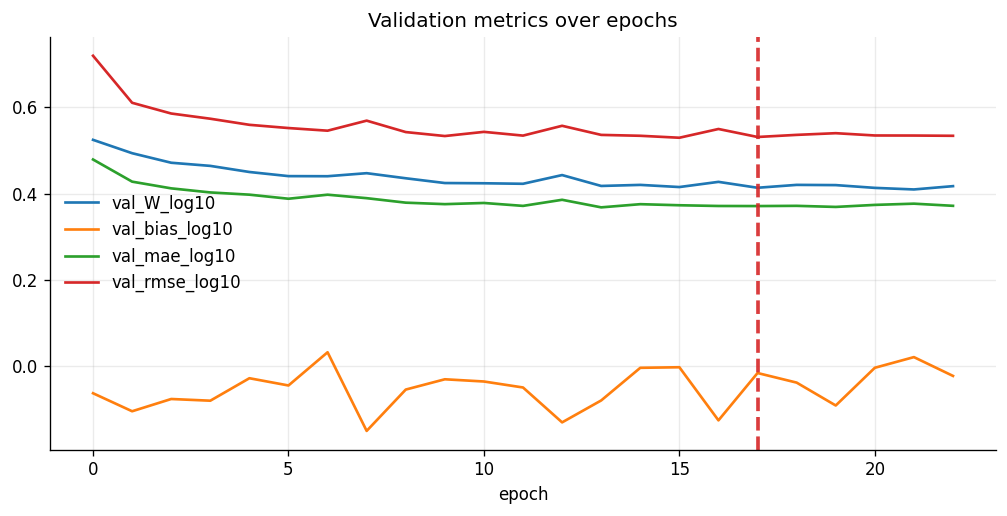

In [28]:
# Key validation metrics over epochs (from metrics.csv)
cols_to_plot = ["val_W_log10", "val_bias_log10", "val_mae_log10", "val_rmse_log10"]
cols_to_plot = [c for c in cols_to_plot if c in df_energy_metrics.columns]

plt.figure(figsize=(8.5, 4.4))
for col in cols_to_plot:
    plt.plot(df_energy_metrics["epoch"], df_energy_metrics[col], label=col, linewidth=1.6)

if "best_model_is_updated" in df_energy_metrics.columns:
    _mask = df_energy_metrics["best_model_is_updated"].astype(bool)
    _best_epoch = int(df_energy_metrics.loc[_mask, "epoch"].max()) if _mask.any() else None
    if _best_epoch is not None:
        plt.axvline(_best_epoch, color="tab:red", linestyle="--", linewidth=2.2, alpha=0.9)

plt.xlabel("epoch")
plt.title("Validation metrics over epochs")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


## 2.4 Snapshot (best vs last epoch)


In [29]:
# Best-epoch vs last-epoch snapshot (epoch-level metrics)
_last = df_energy_metrics.tail(1).copy()
_last.insert(0, "which", "last_epoch")

if best_epoch is not None:
    _best = df_energy_metrics.loc[df_energy_metrics["epoch"] == best_epoch].tail(1).copy()
    _best.insert(0, "which", "best_epoch")
    snapshot = pd.concat([_best, _last], ignore_index=True)
else:
    snapshot = _last

snapshot


,which,epoch,train_loss,val_loss,lr,best_model_is_updated,val_residual_log10_p16,val_residual_log10_p50,val_residual_log10_p84,val_W_log10,val_bias_log10,val_mae_log10,val_rmse_log10
0,best_epoch,17,0.101049,0.115221,0.000413,True,-0.423460,0.065037,0.404102,0.413781,-0.015636,0.371350,0.531475
1,last_epoch,22,0.088514,0.116815,0.000245,False,-0.426323,0.032924,0.408726,0.417525,-0.022349,0.371921,0.534236


# 3. Resource and Time Information (epoch-level)


## 3.1 What this file captures



`resources_and_time.csv` is written **once per epoch** (at the end of validation, via the callback).  
Each row is a **snapshot at an epoch boundary**, not a continuous measurement.

**Implications**
- `epoch_duration_min` is a good proxy for *epoch wall time* (train + val).
- `gpu_util_pct` can be **0% even if the GPU was busy earlier** in the epoch (because it is sampled at the end).
- `sys_mem_used_gb` and `cpu_load_pct` reflect **node-level** state and can be influenced by other processes on the same node.


## 3.2 Quick view and sanity checks

In [30]:
df_energy_resources_and_time.head(5)


,epoch,elapsed_min,epoch_duration_min,rss_gb,sys_mem_used_gb,cpu_load_pct,gpu_util_pct,gpu_mem_used_gb,gpu_mem_total_gb,gpu_mem_util_pct
0,0,16.953,16.953,2.174,146.212,89.06,0.0,17.501,79.647,22.0
1,1,28.293,11.340,2.174,146.046,103.68,25.0,17.501,79.647,22.0
2,2,39.552,11.260,2.173,145.778,109.94,89.0,17.501,79.647,22.0
3,3,50.274,10.722,2.174,62.399,78.03,37.0,17.501,79.647,22.0
4,4,60.591,10.317,2.173,58.316,86.29,0.0,17.501,79.647,22.0


In [31]:
print("Shape:", df_energy_resources_and_time.shape)
print("\nDtypes:")
print(df_energy_resources_and_time.dtypes)

print("\nMissing values per column:")
print(df_energy_resources_and_time.isna().sum())

elapsed = pd.to_numeric(df_energy_resources_and_time["elapsed_min"], errors="coerce")
print("\nElapsed monotonic increasing:", elapsed.is_monotonic_increasing)

Shape: (23, 10)

Dtypes:
epoch                   int64
elapsed_min           float64
epoch_duration_min    float64
rss_gb                float64
sys_mem_used_gb       float64
cpu_load_pct          float64
gpu_util_pct          float64
gpu_mem_used_gb       float64
gpu_mem_total_gb      float64
gpu_mem_util_pct      float64
dtype: object

Missing values per column:
epoch                 0
elapsed_min           0
epoch_duration_min    0
rss_gb                0
sys_mem_used_gb       0
cpu_load_pct          0
gpu_util_pct          0
gpu_mem_used_gb       0
gpu_mem_total_gb      0
gpu_mem_util_pct      0
dtype: int64

Elapsed monotonic increasing: True


## 3.3 Timeline: elapsed time and epoch duration



Two independent ways to estimate epoch duration:
- `epoch_duration_min` (logged)
- `diff(elapsed_min)` (derived)


In [32]:
def _num(col: str):
    """Read a numeric column without modifying the original dataframe."""
    return pd.to_numeric(df_energy_resources_and_time[col], errors="coerce")

epoch = _num("epoch")
elapsed = _num("elapsed_min")
epoch_dur_logged = _num("epoch_duration_min")
epoch_dur_from_elapsed = elapsed.diff()

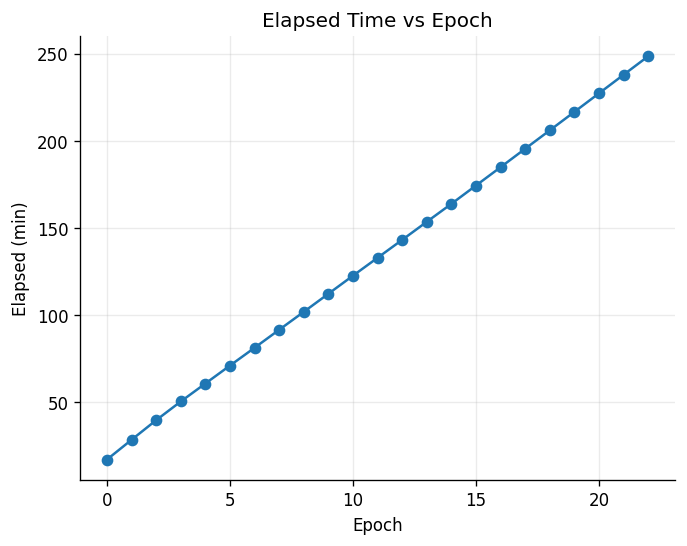

In [33]:
fig, ax = plt.subplots()
ax.plot(epoch, elapsed, marker="o")
ax.set_title("Elapsed Time vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Elapsed (min)")
plt.show()

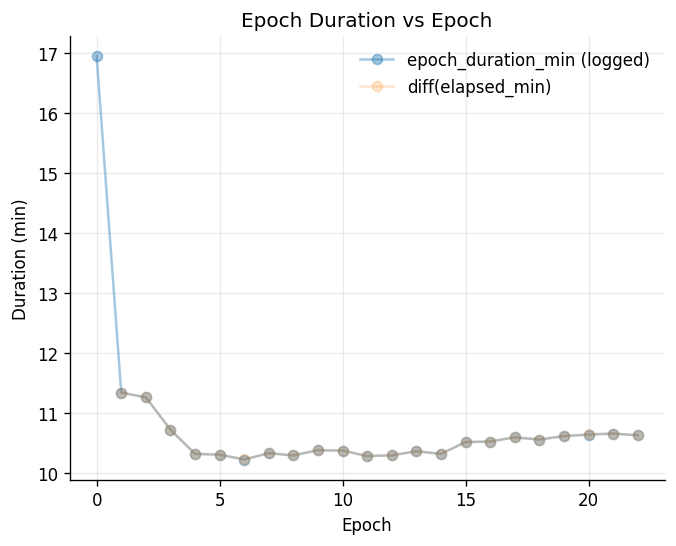

In [34]:
fig, ax = plt.subplots()
ax.plot(epoch, epoch_dur_logged, marker="o", label="epoch_duration_min (logged)", alpha=0.4)
ax.plot(epoch, epoch_dur_from_elapsed, marker="o", label="diff(elapsed_min)", alpha=0.2)
ax.set_title("Epoch Duration vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Duration (min)")
ax.legend()
plt.show()

In [35]:
dur = epoch_dur_logged.dropna()
total_time_min = float(elapsed.dropna().iloc[-1]) if elapsed.notna().any() else np.nan

print(f"Total elapsed (min): {total_time_min:.3f}")
print(
    "Epoch duration (min) | "
    f"mean={dur.mean():.3f}, std={dur.std(ddof=1):.3f}, "
    f"min={dur.min():.3f}, max={dur.max():.3f}"
)

slow_idx = epoch_dur_logged.nlargest(5).index
df_energy_resources_and_time.loc[slow_idx, [
    "epoch", "epoch_duration_min", "cpu_load_pct", "gpu_util_pct",
    "gpu_mem_used_gb", "gpu_mem_util_pct", "rss_gb"
]]

Total elapsed (min): 248.467
Epoch duration (min) | mean=10.803, std=1.371, min=10.223, max=16.953


,epoch,epoch_duration_min,cpu_load_pct,gpu_util_pct,gpu_mem_used_gb,gpu_mem_util_pct,rss_gb
0,0,16.953,89.06,0.0,17.501,22.0,2.174
1,1,11.340,103.68,25.0,17.501,22.0,2.174
2,2,11.260,109.94,89.0,17.501,22.0,2.173
3,3,10.722,78.03,37.0,17.501,22.0,2.174
21,21,10.656,108.05,71.0,26.224,32.9,2.176


## 3.4 Resource curves (epoch-boundary snapshots)



The following plots help answer:
- **Is the run GPU-bound or input/CPU-bound?**
- **Is GPU memory saturated (batch size too large)?**
- **Is RAM growing (potential leak / caching effect)?**


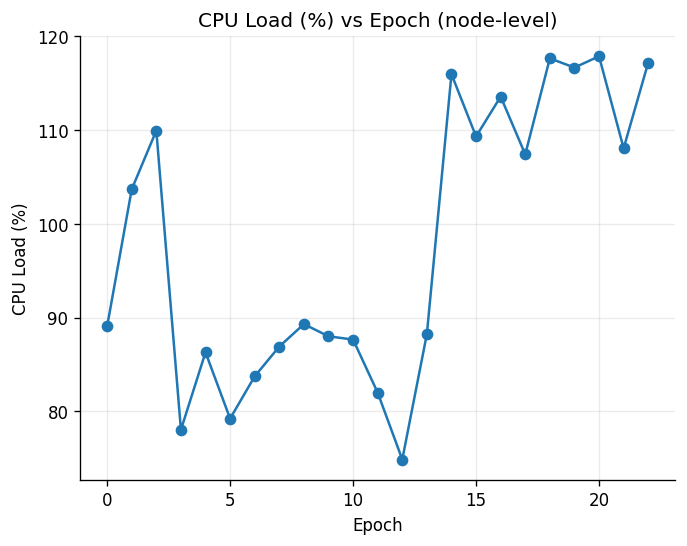

In [36]:
cpu = _num("cpu_load_pct")
fig, ax = plt.subplots()
ax.plot(epoch, cpu, marker="o")
ax.set_title("CPU Load (%) vs Epoch (node-level)")
ax.set_xlabel("Epoch")
ax.set_ylabel("CPU Load (%)")
plt.show()

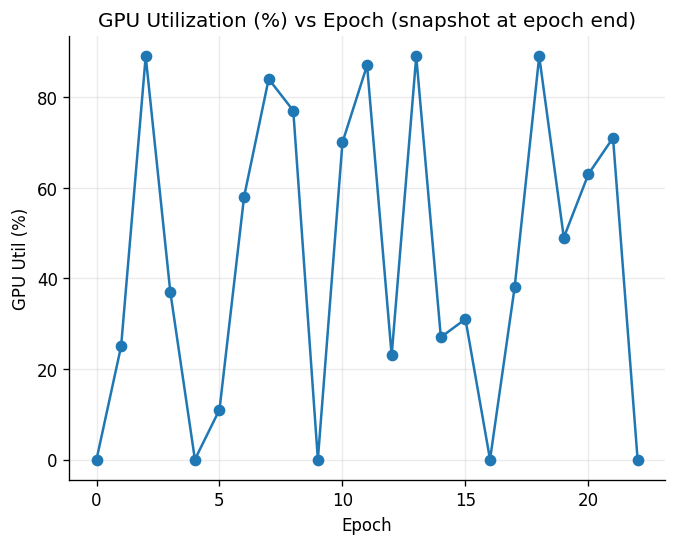

In [37]:
gpu_util = _num("gpu_util_pct")
fig, ax = plt.subplots()
ax.plot(epoch, gpu_util, marker="o")
ax.set_title("GPU Utilization (%) vs Epoch (snapshot at epoch end)")
ax.set_xlabel("Epoch")
ax.set_ylabel("GPU Util (%)")
plt.show()

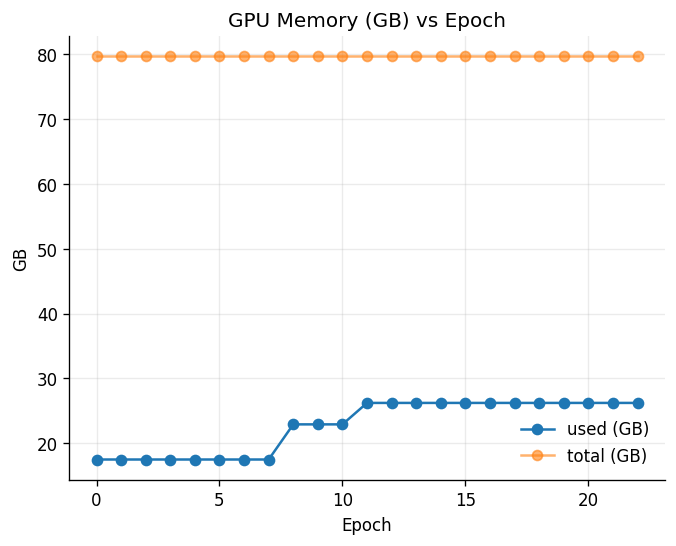

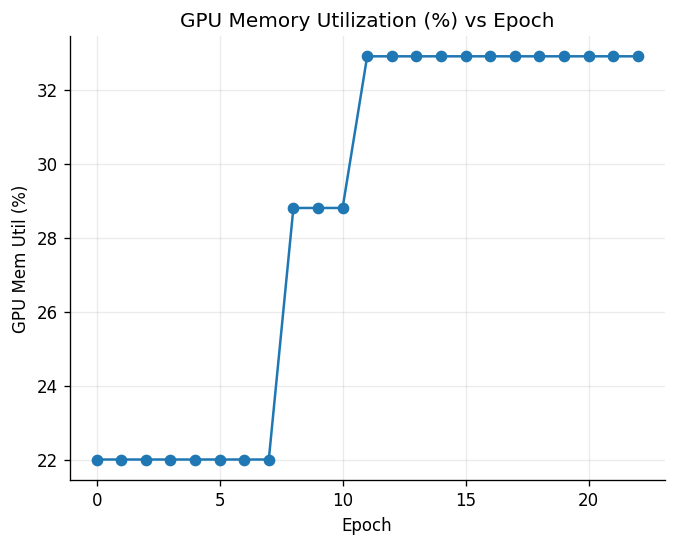

In [38]:
gpu_mem_used = _num("gpu_mem_used_gb")
gpu_mem_total = _num("gpu_mem_total_gb")
gpu_mem_util = _num("gpu_mem_util_pct")

fig, ax = plt.subplots()
ax.plot(epoch, gpu_mem_used, marker="o", label="used (GB)")
ax.plot(epoch, gpu_mem_total, marker="o", label="total (GB)", alpha=0.6)
ax.set_title("GPU Memory (GB) vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("GB")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(epoch, gpu_mem_util, marker="o")
ax.set_title("GPU Memory Utilization (%) vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("GPU Mem Util (%)")
plt.show()

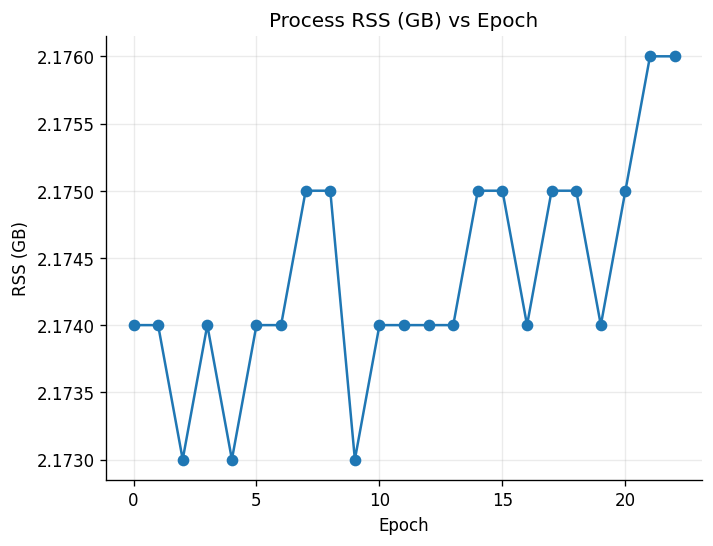

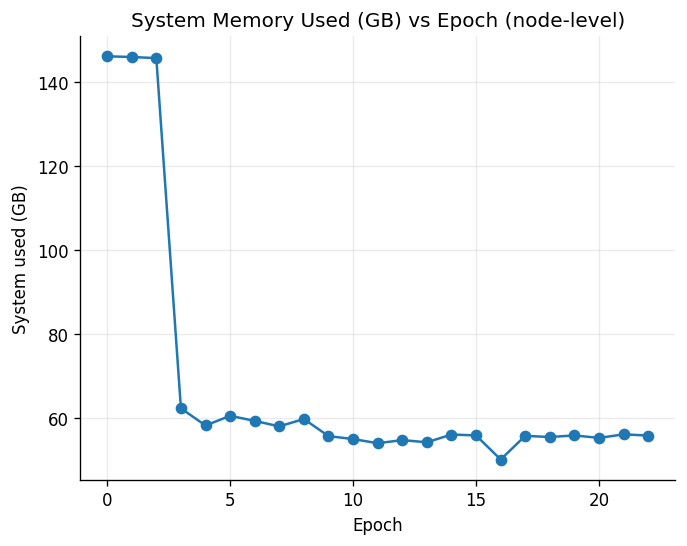

In [39]:
rss = _num("rss_gb")
sys_mem = _num("sys_mem_used_gb")

fig, ax = plt.subplots()
ax.plot(epoch, rss, marker="o")
ax.set_title("Process RSS (GB) vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("RSS (GB)")
plt.show()

fig, ax = plt.subplots()
ax.plot(epoch, sys_mem, marker="o")
ax.set_title("System Memory Used (GB) vs Epoch (node-level)")
ax.set_xlabel("Epoch")
ax.set_ylabel("System used (GB)")
plt.show()

## 3.5 Bottleneck heuristics



These are **heuristics**, not proofs—because the metrics are snapshots.  
Still, they help you decide what to tweak (batch size, num_workers, prefetch, etc.).


In [40]:
# Simple flags (tunable thresholds)
gpu_idle_mask = _num("gpu_util_pct").fillna(0) < 1.0
cpu_high_mask = _num("cpu_load_pct").fillna(0) > 90.0
slow_mask = epoch_dur_logged >= epoch_dur_logged.quantile(0.90)

mask = gpu_idle_mask | cpu_high_mask | slow_mask

cols = [
    "epoch", "epoch_duration_min",
    "cpu_load_pct", "gpu_util_pct",
    "gpu_mem_used_gb", "gpu_mem_util_pct",
    "rss_gb", "sys_mem_used_gb",
]
df_energy_resources_and_time.loc[mask, cols].sort_values("epoch")

,epoch,epoch_duration_min,cpu_load_pct,gpu_util_pct,gpu_mem_used_gb,gpu_mem_util_pct,rss_gb,sys_mem_used_gb
0,0,16.953,89.06,0.0,17.501,22.0,2.174,146.212
1,1,11.340,103.68,25.0,17.501,22.0,2.174,146.046
2,2,11.260,109.94,89.0,17.501,22.0,2.173,145.778
4,4,10.317,86.29,0.0,17.501,22.0,2.173,58.316
9,9,10.379,88.00,0.0,22.917,28.8,2.173,55.787
14,14,10.317,115.96,27.0,26.224,32.9,2.175,56.164
15,15,10.514,109.31,31.0,26.224,32.9,2.175,55.947
16,16,10.523,113.56,0.0,26.224,32.9,2.174,50.215
17,17,10.594,107.40,38.0,26.224,32.9,2.175,55.850
18,18,10.556,117.64,89.0,26.224,32.9,2.175,55.569


In [41]:
# Correlations with epoch duration (numeric view; does NOT modify df)
metrics = [
    "cpu_load_pct", "gpu_util_pct",
    "gpu_mem_used_gb", "gpu_mem_util_pct",
    "rss_gb", "sys_mem_used_gb",
]
X = pd.concat([epoch_dur_logged.rename("epoch_duration_min")] + [_num(m).rename(m) for m in metrics], axis=1)
corr_to_dur = X.corr(numeric_only=True)["epoch_duration_min"].drop("epoch_duration_min").sort_values(ascending=False)

print("Correlation with epoch_duration_min (higher => tends to increase duration):")
corr_to_dur

Correlation with epoch_duration_min (higher => tends to increase duration):


sys_mem_used_gb     0.686119
cpu_load_pct       -0.029383
rss_gb             -0.102405
gpu_util_pct       -0.272898
gpu_mem_used_gb    -0.319831
gpu_mem_util_pct   -0.320108
Name: epoch_duration_min, dtype: float64

## 3.6 How to act on what you see (practical checklist)



**If GPU util is often low while CPU load is high**
- Data pipeline is likely the bottleneck → increase `num_workers`, enable `pin_memory`, `persistent_workers`,
  adjust `prefetch_factor`, consider faster storage / caching, avoid heavy Python transforms per batch.

**If GPU memory is close to full**
- Reduce `batch_size` (or model size), consider gradient accumulation instead of huge batches.

**If GPU memory is stable but epoch duration increases**
- Check for CPU/RAM pressure, background jobs on the same node, or increasing dataloader overhead.

**If process RSS grows steadily**
- Possible memory leak or accumulating caches → inspect dataloader caching, repeated object creation,
  and keep an eye on Python lists that grow across epochs.
